In [21]:
CSV_PATH = "../../classification/output/props_with_predictions.csv"

import pandas as pd

df = pd.read_csv(CSV_PATH)
df.head()

,image,label,intensity_mean_red,intensity_std_red,intensity_p10_red,intensity_p20_red,intensity_p30_red,intensity_p40_red,intensity_p50_red,intensity_p60_red,...,red_glcm_homogeneity_mean,red_glcm_homogeneity_std,red_glcm_ASM_mean,red_glcm_ASM_std,red_glcm_energy_mean,red_glcm_energy_std,red_glcm_correlation_mean,red_glcm_correlation_std,prediction,probability
0,0246_CHST11KO_BS_AT8_epsilon5_first_2026-04-24...,1,214.269323,74.233065,121.0,134.0,165.0,195.0,217.0,233.0,...,0.458725,0.083374,0.038147,0.011476,0.192876,0.030762,0.793874,0.133526,0,0.311333
1,0246_CHST11KO_BS_AT8_epsilon5_first_2026-04-24...,2,221.887827,79.548309,117.0,125.0,158.0,199.0,232.0,256.0,...,0.416450,0.066163,0.051835,0.015065,0.224903,0.035407,0.700291,0.146155,0,0.474000
2,0246_CHST11KO_BS_AT8_epsilon5_first_2026-04-24...,3,137.608778,24.982785,114.0,118.0,121.0,124.0,129.0,137.0,...,0.459821,0.087630,0.058343,0.014275,0.239510,0.031274,0.863347,0.095839,0,0.326167
3,0246_CHST11KO_BS_AT8_epsilon5_first_2026-04-24...,4,181.327679,61.296089,115.0,119.0,124.0,138.0,166.5,197.0,...,0.313775,0.064911,0.030379,0.009888,0.171631,0.030355,0.712592,0.152849,0,0.352000
4,0246_CHST11KO_BS_AT8_epsilon5_first_2026-04-24...,5,117.090595,6.471247,109.0,112.0,113.0,115.0,117.0,118.0,...,0.269116,0.038458,0.025875,0.009710,0.157476,0.032808,0.478386,0.111113,0,0.124800


In [22]:
# Count cells of each class per image
counts = (
    df.groupby(["image", "prediction"])
      .size()
      .unstack(fill_value=0)
)

# Total number of classified cells
counts["total"] = counts.sum(axis=1)

# Percentages
for cls in counts.columns[:-1]:  # exclude "total"
    counts[f"{cls}_percent"] = 100 * counts[cls] / counts["total"]

# Convert image index back to a column
summary = counts.reset_index()

print(summary)

prediction                                              image      0     1  \
0           0246_CHST11KO_BS_AT8_epsilon5_first_2026-04-24...   3112  1303   
1           0246_CHST11KO_BS_AT8_epsilon5_second_2026-04-2...   1806   370   
2           0246_CHST11KO_BS_AT8_epsilon5_third_2026-04-24...   2249   386   
3           0246_CHST11KO_HC_AT8_epsilon5_first_2026-04-24...   5760   512   
4           0246_CHST11KO_HC_AT8_epsilon5_second_2026-04-2...   4014   168   
..                                                        ...    ...   ...   
135         F2445_CHST11KO+P301S_MC_AT8_epsilon1_second_20...   2937   659   
136         F2445_CHST11KO+P301S_MC_AT8_epsilon1_third_202...   3486   408   
137         NC_31.3u-26.2.25_WT+PLA_BS_AT8_alpha5_first_20...  22424     1   
138         NC_31.3u-26.2.25_WT+PLA_HC_AT8_alpha5_first_20...   1237     0   
139         NC_31.3u-26.2.25_WT+PLA_MC_AT8_alpha5_first_20...   6633     0   

prediction  total   0_percent  1_percent  
0            4415   

In [23]:
# Counts per class
counts = (
    df.groupby(["image", "prediction"])
      .size()
      .unstack(fill_value=0)
)

counts["total_cells"] = counts.sum(axis=1)

# Percentages
# skip total_cells
for cls in counts.columns[:-1]:
    counts[f"{cls}_percent"] = 100 * counts[cls] / counts["total_cells"]

# Mean and std probability per class
prob_stats = (
    df.groupby(["image", "prediction"])["probability"]
      .agg(["mean", "std"])
      .unstack()
)

# Flatten the MultiIndex columns
prob_stats.columns = [
    f"{cls}_{stat}_probability"
    for stat, cls in prob_stats.columns
]

# Combine everything
summary = (
    counts
    .join(prob_stats)
    .reset_index()
)

summary

,image,0,1,total_cells,0_percent,1_percent,0_mean_probability,1_mean_probability,0_std_probability,1_std_probability
0,0246_CHST11KO_BS_AT8_epsilon5_first_2026-04-24...,3112,1303,4415,70.486976,29.513024,0.361978,0.594096,0.087817,0.069625
1,0246_CHST11KO_BS_AT8_epsilon5_second_2026-04-2...,1806,370,2176,82.996324,17.003676,0.356618,0.550593,0.093443,0.040869
2,0246_CHST11KO_BS_AT8_epsilon5_third_2026-04-24...,2249,386,2635,85.351044,14.648956,0.341207,0.547836,0.100069,0.037808
3,0246_CHST11KO_HC_AT8_epsilon5_first_2026-04-24...,5760,512,6272,91.836735,8.163265,0.336594,0.547045,0.081144,0.040989
4,0246_CHST11KO_HC_AT8_epsilon5_second_2026-04-2...,4014,168,4182,95.982783,4.017217,0.336501,0.534849,0.080017,0.030596
...,...,...,...,...,...,...,...,...,...,...
135,F2445_CHST11KO+P301S_MC_AT8_epsilon1_second_20...,2937,659,3596,81.674082,18.325918,0.327407,0.574222,0.096468,0.058246
136,F2445_CHST11KO+P301S_MC_AT8_epsilon1_third_202...,3486,408,3894,89.522342,10.477658,0.318856,0.562058,0.100610,0.059451
137,NC_31.3u-26.2.25_WT+PLA_BS_AT8_alpha5_first_20...,22424,1,22425,99.995541,0.004459,0.248896,0.519633,0.037353,NaN
138,NC_31.3u-26.2.25_WT+PLA_HC_AT8_alpha5_first_20...,1237,0,1237,100.000000,0.000000,0.310359,NaN,0.046035,NaN


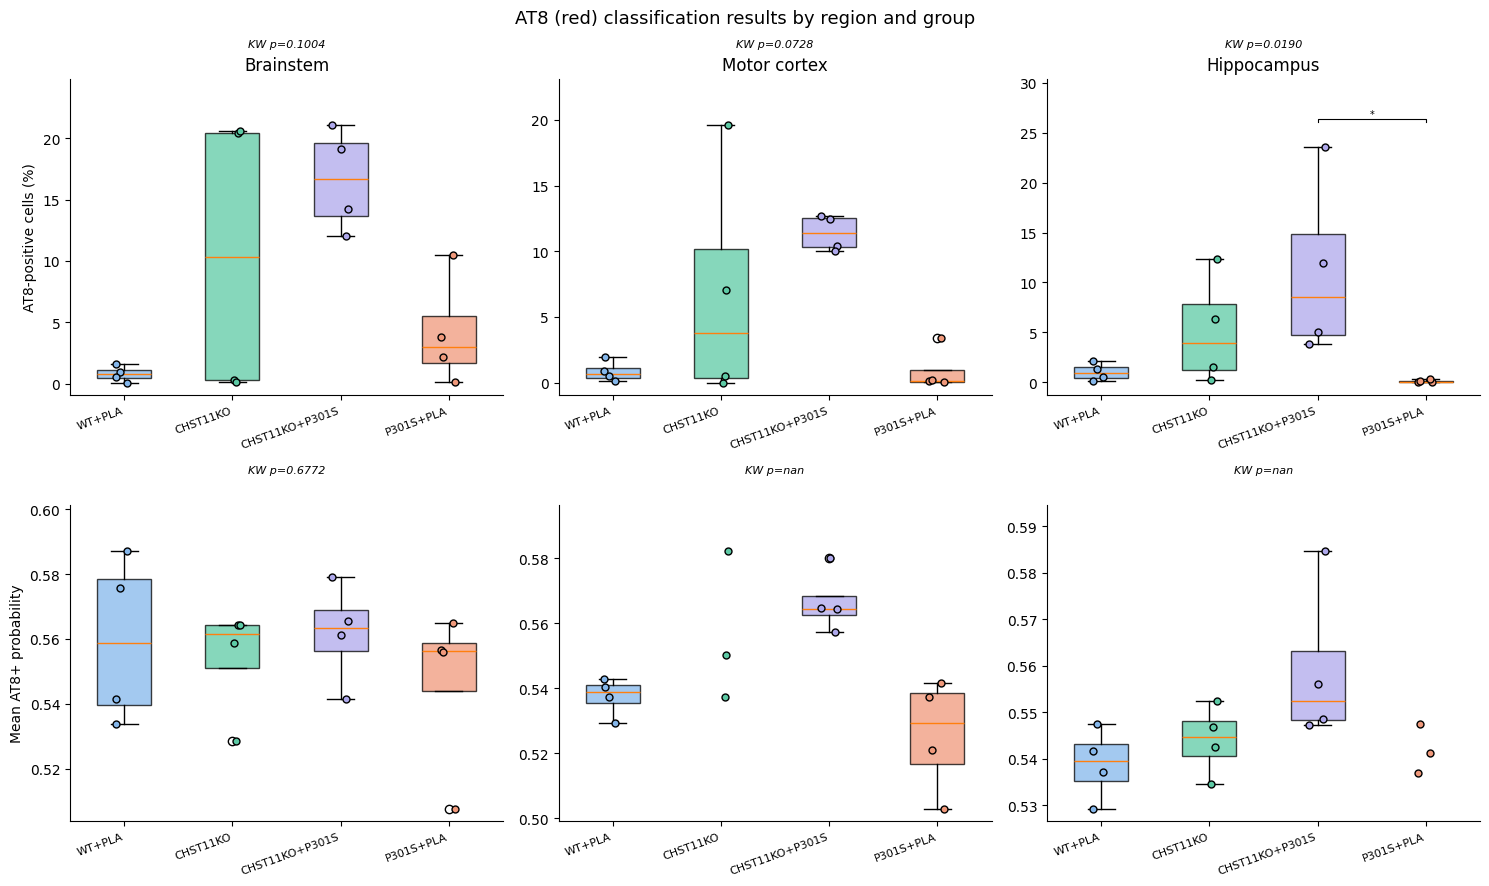

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy import stats
import scikit_posthocs as sp

GROUPS       = ["CHST11KO+P301S", "CHST11KO", "WT+PLA", "P301S+PLA"]  # longest first
GROUP_ORDER  = ["WT+PLA", "CHST11KO", "CHST11KO+P301S", "P301S+PLA"]
COLORS       = {"WT+PLA": "#85B7EB", "CHST11KO": "#5DCAA5",
                 "CHST11KO+P301S": "#AFA9EC", "P301S+PLA": "#F0997B"}
REGIONS        = ["BS", "MC", "HC"]
REGION_LABELS  = {"BS": "Brainstem", "MC": "Motor cortex", "HC": "Hippocampus"}
METRICS        = [("1_percent", "AT8-positive cells (%)"),
                   ("1_mean_probability", "Mean AT8+ probability")]

detect_group  = lambda n: next((g for g in GROUPS if g in n), None)
detect_region = lambda n: next((r for r in REGIONS if r in n.replace("-", "_").split("_")), None)
animal_id     = lambda n: n.split("_")[0]
sig_label     = lambda p: "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"

df = summary[~summary["image"].str.contains("NC_")].copy()
df["group"], df["region"], df["animal"] = (
    df["image"].apply(detect_group), df["image"].apply(detect_region), df["image"].apply(animal_id)
)
df = df.dropna(subset=["group", "region"])

animal_avg = df.groupby(["animal", "group", "region"])[["1_percent", "1_mean_probability"]].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, (col_name, label) in enumerate(METRICS):
    for c, region in enumerate(REGIONS):
        ax = axes[row][c]
        rdf = animal_avg[animal_avg.region == region]
        groups = [g for g in GROUP_ORDER if g in rdf.group.values]
        data   = [rdf.loc[rdf.group == g, col_name].values for g in groups]
        colors = [COLORS[g] for g in groups]
        if row == 0: ax.set_title(REGION_LABELS[region])
        if c == 0:   ax.set_ylabel(label)
        if not groups:
            ax.text(.5, .5, "no data", ha="center", va="center", transform=ax.transAxes)
            continue

        bp = ax.boxplot(data, patch_artist=True, widths=0.5)
        for patch, cl in zip(bp["boxes"], colors):
            patch.set_facecolor(cl); patch.set_alpha(.75)
        rng = np.random.default_rng(0)
        for i, (d, cl) in enumerate(zip(data, colors), 1):
            ax.scatter(np.full(len(d), i) + rng.uniform(-.08, .08, len(d)), d,
                       color=cl, edgecolors="black", s=25, zorder=3)
        ax.set_xticks(range(1, len(groups) + 1))
        ax.set_xticklabels(groups, rotation=20, ha="right", fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

        if len(groups) >= 2 and all(len(d) > 0 for d in data):
            kw_p = stats.kruskal(*data).pvalue
            dunn = sp.posthoc_dunn(
                pd.DataFrame({"val": np.concatenate(data),
                              "group": np.concatenate([[g]*len(d) for g, d in zip(groups, data)])}),
                val_col="val", group_col="group", p_adjust="bonferroni"
            )
            ax.text(.5, 1.1, f"KW p={kw_p:.4f}", transform=ax.transAxes, ha="center", fontsize=8, style="italic")

            y, step, k = ax.get_ylim()[1], (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.1, 0
            for g1, g2 in combinations(groups, 2):
                p = dunn.loc[g1, g2]
                if p < 0.05:
                    i, j = groups.index(g1) + 1, groups.index(g2) + 1
                    yb = y + step * (k + 0.5); k += 1
                    ax.plot([i, i, j, j], [yb, yb + step*.15, yb + step*.15, yb], lw=0.8, color="black")
                    ax.text((i + j) / 2, yb + step*.2, sig_label(p), ha="center", fontsize=7)
            ax.set_ylim(ax.get_ylim()[0], y + step * (k + 1.2))

fig.suptitle("AT8 (red) classification results by region and group", fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
summary.to_csv("../../classification/output/red_summary_classification.csv", index=False)

In [15]:
df.hist(column="probability", by="prediction", bins=20, figsize=(12, 6), layout=(1, 3))

KeyError: 'prediction'